Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.88      0.95      0.92       601
     Dropout       0.88      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



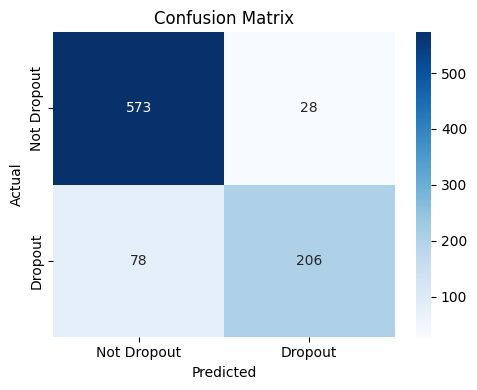

The student is NOT predicted to DROP out.
Dropout Probability: 8.00%
Not Dropout Probability: 92.00%


In [4]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
data = fetch_ucirepo(id=697)

X = data.data.features
y = data.data.targets

y = (y == 'Dropout').astype(int)

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train, y_train.values.ravel()) # Train the model

y_pred = clf.predict(X_test)


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Dropout", "Dropout"]))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Dropout", "Dropout"],
            yticklabels=["Not Dropout", "Dropout"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


sample = X_test.iloc[[21]]
predicted_class = clf.predict(sample)[0]
predicted_proba = clf.predict_proba(sample)[0]
if predicted_class == 1:
    print("The student is at risk of DROPPING out.")
else:
    print("The student is NOT predicted to DROP out.")

print(f"Dropout Probability: {predicted_proba[1]*100:.2f}%")
print(f"Not Dropout Probability: {predicted_proba[0]*100:.2f}%")


